# TP1 · Notebook 03 — Modelos SARIMA, evaluación y pronóstico
Puntos 5, 6, 7, 8, 9 y 12 de la consigna. Insumo: transformación y órdenes $(d, D)$ fijados en el Notebook 02;
acá se buscan los órdenes $(p, q, P, Q)$ dentro de esos $(d, D)$.

## 1. Entorno y carga de los insumos del Notebook 02

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings, os, glob, time, itertools
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import acf

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (13, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})

# ---------------- configuración ----------------
NOMBRE_CARPETA = 'DATASETS'
RUTA_DIRECTA   = '/content/drive/MyDrive/TP Analisis de Series Temporales/DATASETS'
S = 12
COLORES = {'nieve': 'steelblue', 'savi': 'seagreen', 'agua': 'indianred'}
# -----------------------------------------------

try:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
except ImportError:
    pass

CARPETA_DATOS = RUTA_DIRECTA if os.path.isdir(RUTA_DIRECTA) else next(
    (h for raiz in ['/content/drive/MyDrive', '/content', '.'] for n in range(4)
     for h in glob.glob(os.path.join(raiz, *(['*'] * n), NOMBRE_CARPETA)) if os.path.isdir(h)), None)
assert CARPETA_DATOS, f'No se encontró la carpeta {NOMBRE_CARPETA}. Ajustar RUTA_DIRECTA.'
CARPETA_SALIDA = os.path.join(CARPETA_DATOS.rsplit('/', 1)[0], 'OUTPUTS')
os.makedirs(CARPETA_SALIDA, exist_ok=True)

localizar = lambda p: next(iter(sorted(glob.glob(os.path.join(CARPETA_SALIDA, '**', p), recursive=True))), None)
p_series, p_decision = localizar('02_series_estacionarizadas.csv'), localizar('02_decision_ordenes.csv')
assert p_series and p_decision, 'Faltan los CSV del Notebook 02: ejecutarlo antes que este notebook.'

df_series   = pd.read_csv(p_series, index_col=0, parse_dates=True).asfreq('MS')
df_decision = pd.read_csv(p_decision, index_col=0)

# Se usa la versión YA transformada SIN diferenciar: SARIMAX recibe (d, D) en el orden
# y hace la diferenciación internamente (aplicarla dos veces sería un error).
SERIES_T       = {k: df_series[f'{k}_transformada'].dropna() for k in ['nieve', 'savi', 'agua']}
ORDENES        = {k: {'d': int(df_decision.loc[k, 'd']), 'D': int(df_decision.loc[k, 'D'])} for k in SERIES_T}
TRANSFORMACION = {k: df_decision.loc[k, 'transformación'] for k in SERIES_T}

display(df_decision)
for k, v in SERIES_T.items():
    print(f'{k:6s} {v.index.min():%Y-%m} a {v.index.max():%Y-%m}  n={len(v)}  '
          f'transf.: {TRANSFORMACION[k]:8s} d={ORDENES[k]["d"]} D={ORDENES[k]["D"]}')

Mounted at /content/drive


,n,período,transformación,d,D,s,n tras diferenciar,modelo base
serie,,,,,,,,
nieve,471,1986-01 a 2025-03,log,0,0,12,471,"SARIMA(p,0,q)(P,0,Q)[12]"
savi,105,2016-07 a 2025-03,ninguna,1,1,12,92,"SARIMA(p,1,q)(P,1,Q)[12]"
agua,105,2016-07 a 2025-03,ninguna,1,0,12,104,"SARIMA(p,1,q)(P,0,Q)[12]"


nieve  1986-01 a 2025-03  n=471  transf.: log      d=0 D=0
savi   2016-07 a 2025-03  n=105  transf.: ninguna  d=1 D=1
agua   2016-07 a 2025-03  n=105  transf.: ninguna  d=1 D=0


## 2. Partición training / testing *(punto 6, primera mitad)*

El testing set cubre un número entero de ciclos anuales: 24 meses para `nieve` (471 obs) y 12 para `savi` y `agua`
(105 obs, que además pierden observaciones por la diferenciación).

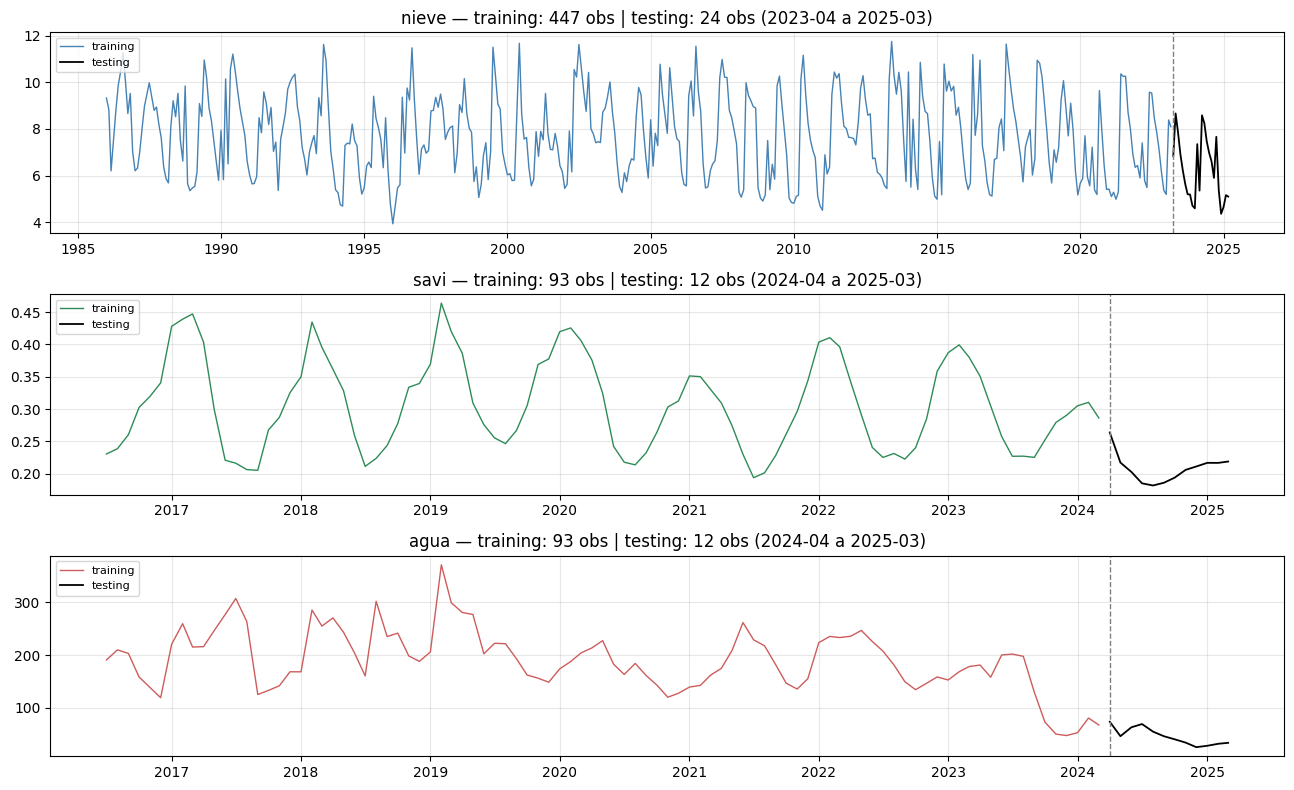

In [3]:
TEST_SIZE = {'nieve': 24, 'savi': 12, 'agua': 12}
TRAIN = {k: v.iloc[:-TEST_SIZE[k]] for k, v in SERIES_T.items()}
TEST  = {k: v.iloc[-TEST_SIZE[k]:] for k, v in SERIES_T.items()}

fig, axes = plt.subplots(3, 1, figsize=(13, 8))
for ax, nombre in zip(axes, SERIES_T):
    ax.plot(TRAIN[nombre], color=COLORES[nombre], lw=1, label='training')
    ax.plot(TEST[nombre], color='black', lw=1.3, label='testing')
    ax.axvline(TEST[nombre].index[0], color='grey', ls='--', lw=1)
    ax.set_title(f'{nombre} — training: {len(TRAIN[nombre])} obs | testing: {len(TEST[nombre])} obs '
                 f'({TEST[nombre].index[0]:%Y-%m} a {TEST[nombre].index[-1]:%Y-%m})')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

## 3. Grilla SARIMA y selección por criterios de información *(punto 5)*

Se recorren todas las combinaciones $(p, q, P, Q)$ manteniendo fijos los $(d, D)$ del Notebook 02, estimando
**sólo sobre el training set**. AIC $=-2\ln\hat L + 2k$ · BIC $=-2\ln\hat L + k\ln n$ (penaliza más, prefiere
modelos más parcos). Los ajustes que no convergen se descartan.

In [4]:
GRID = {'nieve': {'p': range(0, 4), 'q': range(0, 3), 'P': range(0, 2), 'Q': range(0, 2)},
        'savi' : {'p': range(0, 3), 'q': range(0, 3), 'P': range(0, 2), 'Q': range(0, 2)},
        'agua' : {'p': range(0, 4), 'q': range(0, 3), 'P': range(0, 2), 'Q': range(0, 2)}}


def ajustar(serie, order, seasonal_order):
    return SARIMAX(serie, order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)


tablas_grilla = {}
for nombre, g in GRID.items():
    t0, o, filas = time.time(), ORDENES[nombre], []
    for p, q, P, Q in itertools.product(g['p'], g['q'], g['P'], g['Q']):
        try:
            r = ajustar(TRAIN[nombre], (p, o['d'], q), (P, o['D'], Q, S))
            filas.append({'p': p, 'q': q, 'P': P, 'Q': Q,
                          'AIC': r.aic, 'BIC': r.bic, 'nparams': r.df_model})
        except Exception:
            continue
    tablas_grilla[nombre] = pd.DataFrame(filas).sort_values('AIC').reset_index(drop=True)
    print(f'{nombre}: {len(filas)} modelos convergieron ({time.time() - t0:.0f} s)')

for nombre, t in tablas_grilla.items():
    print(f'\n=== {nombre} — mejores por AIC ===')
    display(t.head(6).round(3))
    b = t.sort_values('BIC').iloc[0]
    print(f'Mejor por BIC: p={int(b.p)}, q={int(b.q)}, P={int(b.P)}, Q={int(b.Q)} '
          f'(AIC={b.AIC:.2f}, BIC={b.BIC:.2f})')

nieve: 48 modelos convergieron (70 s)
savi: 36 modelos convergieron (48 s)
agua: 48 modelos convergieron (17 s)

=== nieve — mejores por AIC ===


,p,q,P,Q,AIC,BIC,nparams
0,3,2,1,0,14.000,42.718,7
1,3,2,1,1,16.000,48.820,8
2,3,1,1,1,1484.092,1512.810,7
3,2,2,1,1,1485.640,1514.358,7
4,2,1,1,1,1486.427,1511.042,6
5,1,2,1,1,1500.591,1525.206,6


Mejor por BIC: p=3, q=2, P=1, Q=0 (AIC=14.00, BIC=42.72)

=== savi — mejores por AIC ===


,p,q,P,Q,AIC,BIC,nparams
0,0,1,0,1,-372.766,-365.620,3
1,1,0,0,1,-371.655,-364.509,3
2,0,2,0,1,-371.109,-361.581,4
3,0,1,1,1,-371.046,-361.518,4
4,1,1,0,1,-370.972,-361.444,4
5,2,0,0,1,-370.928,-361.400,4


Mejor por BIC: p=0, q=1, P=0, Q=1 (AIC=-372.77, BIC=-365.62)

=== agua — mejores por AIC ===


,p,q,P,Q,AIC,BIC,nparams
0,1,1,1,1,938.134,950.743,5
1,2,1,1,1,939.743,954.873,6
2,1,2,1,1,939.865,954.996,6
3,3,1,1,1,939.869,957.522,7
4,2,2,1,1,940.823,958.476,7
5,1,1,1,0,941.217,951.304,4


Mejor por BIC: p=1, q=1, P=1, Q=1 (AIC=938.13, BIC=950.74)


### Modelos elegidos, significatividad individual y global

Individual: test $z$ de Wald del `summary()`. Global: razón de verosimilitudes contra el modelo sin términos
AR/MA, $\text{SARIMA}(0,d,0)(0,D,0)_{12}$, con $\text{LR}=2(\ln\hat L_{\text{comp}}-\ln\hat L_{\text{rest}})
\sim \chi^2_k$.

In [5]:
# ---- EDITAR tras leer la grilla ----
# nieve: se opta por el de menor AIC (3,0,1)(1,0,1) y no por el de menor BIC, porque ar.L3 resulta significativo
MODELOS = {'nieve': {'order': (3, 0, 1), 'seasonal_order': (1, 0, 1, S)},
           'savi' : {'order': (0, 1, 1), 'seasonal_order': (0, 1, 1, S)},
           'agua' : {'order': (1, 1, 1), 'seasonal_order': (1, 0, 1, S)}}

AJUSTES, filas = {}, []
for nombre, m in MODELOS.items():
    o = ORDENES[nombre]
    AJUSTES[nombre] = ajustar(TRAIN[nombre], m['order'], m['seasonal_order'])
    print(f'\n=== {nombre}  SARIMA{m["order"]}x{m["seasonal_order"]}  '
          f'(AIC={AJUSTES[nombre].aic:.2f}, BIC={AJUSTES[nombre].bic:.2f}) ===')
    display(AJUSTES[nombre].summary().tables[1])

    base = ajustar(TRAIN[nombre], (0, o['d'], 0), (0, o['D'], 0, S))   # sin términos AR/MA
    lr, gl = 2 * (AJUSTES[nombre].llf - base.llf), AJUSTES[nombre].df_model - base.df_model
    filas.append({'serie': nombre, 'modelo': f'SARIMA{m["order"]}x{m["seasonal_order"]}',
                  'llf modelo': AJUSTES[nombre].llf, 'llf base (0,d,0)(0,D,0)': base.llf,
                  'LR': lr, 'gl': gl, 'p-valor': stats.chi2.sf(lr, gl)})

print('\nSignificatividad global (H0: los términos AR/MA no aportan):')
display(pd.DataFrame(filas).set_index('serie').round(4))


=== nieve  SARIMA(3, 0, 1)x(1, 0, 1, 12)  (AIC=1484.09, BIC=1512.81) ===


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,1.3427,0.037,36.055,0.000,1.270,1.416
ar.L2,-0.2450,0.059,-4.120,0.000,-0.362,-0.128
ar.L3,-0.0988,0.044,-2.226,0.026,-0.186,-0.012
ma.L1,-0.9794,0.018,-54.540,0.000,-1.015,-0.944
ar.S.L12,0.9981,0.003,365.958,0.000,0.993,1.003
ma.S.L12,-0.9503,0.033,-28.964,0.000,-1.015,-0.886
sigma2,1.4775,0.087,17.068,0.000,1.308,1.647



=== savi  SARIMA(0, 1, 1)x(0, 1, 1, 12)  (AIC=-372.77, BIC=-365.62) ===


,coef,std err,z,P>|z|,[0.025,0.975]
ma.L1,-0.2848,0.107,-2.663,0.008,-0.494,-0.075
ma.S.L12,-0.6592,0.120,-5.479,0.000,-0.895,-0.423
sigma2,0.0005,7.58e-05,6.227,0.000,0.000,0.001



=== agua  SARIMA(1, 1, 1)x(1, 0, 1, 12)  (AIC=938.13, BIC=950.74) ===


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.6755,0.145,4.659,0.000,0.391,0.960
ma.L1,-0.9442,0.080,-11.836,0.000,-1.101,-0.788
ar.S.L12,0.9696,0.131,7.422,0.000,0.714,1.226
ma.S.L12,-0.8516,0.334,-2.547,0.011,-1.507,-0.196
sigma2,1299.8353,262.609,4.950,0.000,785.131,1814.539



Significatividad global (H0: los términos AR/MA no aportan):


,modelo,llf modelo,"llf base (0,d,0)(0,D,0)",LR,gl,p-valor
serie,,,,,,
nieve,"SARIMA(3, 0, 1)x(1, 0, 1, 12)",-735.0461,-1559.8756,1649.6590,6,0.0000
savi,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",189.3830,177.0948,24.5764,2,0.0000
agua,"SARIMA(1, 1, 1)x(1, 0, 1, 12)",-464.0669,-474.7213,21.3088,4,0.0003


## 4. Métricas de performance sobre el testing set *(punto 6, segunda mitad)*

Todo se evalúa en la **escala original** (`expm1` para `nieve`). MAE en unidades originales · RMSE penaliza los
errores grandes · sMAPE porcentual y acotado en $[0\%, 200\%]$ (se prefiere al MAPE porque `nieve` tiene valores
cercanos a cero).

,modelo,MAE,RMSE,sMAPE %
serie,,,,
nieve,"SARIMA(3, 0, 1)x(1, 0, 1, 12)",2887.100,4166.343,119.461
savi,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",0.037,0.042,19.558
agua,"SARIMA(1, 1, 1)x(1, 0, 1, 12)",64.241,67.463,84.871


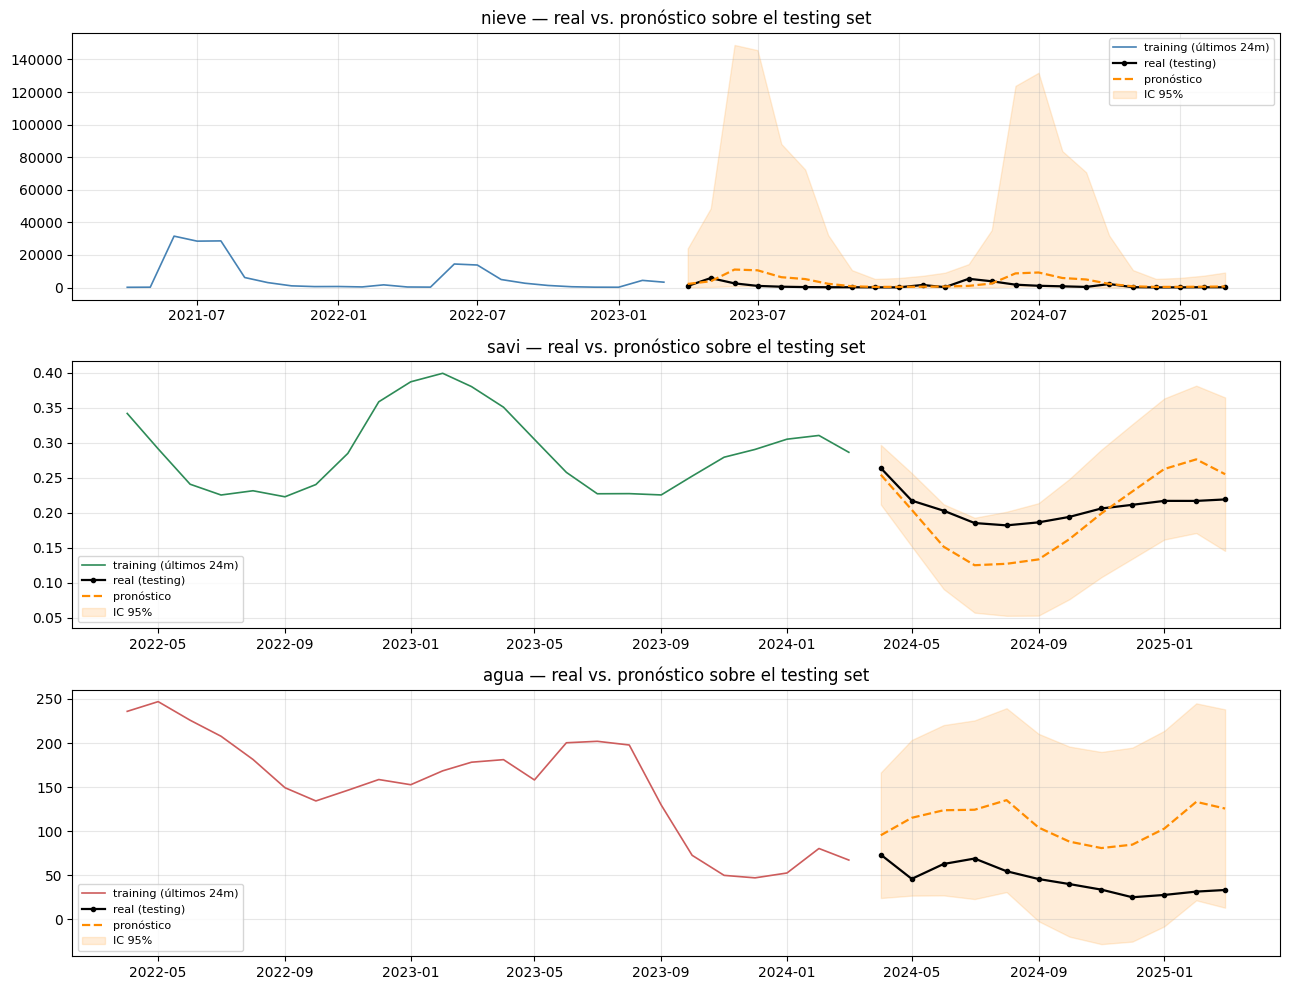

In [6]:
def invertir(nombre, x):
    '''Deshace la transformación de varianza para volver a la escala original.'''
    return np.expm1(x) if TRANSFORMACION[nombre] == 'log' else x


def metricas(y_real, y_pred):
    e = np.asarray(y_real) - np.asarray(y_pred)
    return (np.mean(np.abs(e)), np.sqrt(np.mean(e**2)),
            100 * np.mean(2 * np.abs(e) / (np.abs(y_real) + np.abs(y_pred) + 1e-9)))


PRONOSTICOS_TEST, filas = {}, []
for nombre, m in MODELOS.items():
    fc = AJUSTES[nombre].get_forecast(steps=TEST_SIZE[nombre])
    PRONOSTICOS_TEST[nombre] = {'pred': fc.predicted_mean, 'ci': fc.conf_int(alpha=0.05)}
    mae, rmse, smape = metricas(invertir(nombre, TEST[nombre]).values,
                                invertir(nombre, fc.predicted_mean).values)
    filas.append({'serie': nombre, 'modelo': f'SARIMA{m["order"]}x{m["seasonal_order"]}',
                  'MAE': mae, 'RMSE': rmse, 'sMAPE %': smape})
display(pd.DataFrame(filas).set_index('serie').round(3))

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, nombre in zip(axes, SERIES_T):
    ci = invertir(nombre, PRONOSTICOS_TEST[nombre]['ci'])
    ax.plot(invertir(nombre, TRAIN[nombre].iloc[-24:]), color=COLORES[nombre], lw=1.2,
            label='training (últimos 24m)')
    ax.plot(invertir(nombre, TEST[nombre]), color='black', lw=1.6, marker='o', ms=3, label='real (testing)')
    ax.plot(invertir(nombre, PRONOSTICOS_TEST[nombre]['pred']), color='darkorange', lw=1.6, ls='--',
            label='pronóstico')
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='darkorange', alpha=0.15, label='IC 95%')
    ax.set_title(f'{nombre} — real vs. pronóstico sobre el testing set')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Comparación con otros modelos estimados *(punto 7)*

Contra **naive estacional** ($\hat Y_t = Y_{t-12}$, piso mínimo de cualquier serie estacional) y
**Holt-Winters** aditivo. A `nieve` no se le da tendencia: el Notebook 02 la caracterizó como estacionaria con
ciclo ($d=0$); a `savi` y `agua` ($d=1$) sí, amortiguada.

In [7]:
COMPARACION = {}
for nombre in SERIES_T:
    n_test = TEST_SIZE[nombre]
    y_real = invertir(nombre, TEST[nombre]).values

    naive = SERIES_T[nombre].shift(S).iloc[-n_test:]
    con_tend = nombre != 'nieve'
    hw = ExponentialSmoothing(TRAIN[nombre], trend=('add' if con_tend else None), seasonal='add',
                              seasonal_periods=S, damped_trend=con_tend).fit()

    COMPARACION[nombre] = pd.DataFrame(
        [{'modelo': etq, **dict(zip(['MAE', 'RMSE', 'sMAPE %'],
                                    metricas(y_real, invertir(nombre, pred).values)))}
         for etq, pred in [('SARIMA (elegido)', PRONOSTICOS_TEST[nombre]['pred']),
                           ('Naive estacional', naive),
                           ('Holt-Winters',     hw.forecast(n_test))]]).set_index('modelo')
    print(f'=== {nombre} ===')
    display(COMPARACION[nombre].round(3))

=== nieve ===


,MAE,RMSE,sMAPE %
modelo,,,
SARIMA (elegido),2887.100,4166.343,119.461
Naive estacional,2339.685,4134.679,94.083
Holt-Winters,5277.165,7917.533,135.098


=== savi ===


,MAE,RMSE,sMAPE %
modelo,,,
SARIMA (elegido),0.037,0.042,19.558
Naive estacional,0.068,0.071,27.565
Holt-Winters,0.044,0.051,23.297


=== agua ===


,MAE,RMSE,sMAPE %
modelo,,,
SARIMA (elegido),64.241,67.463,84.871
Naive estacional,74.657,88.631,81.736
Holt-Winters,23.041,27.669,66.893


## 6. Diagnóstico de residuos *(punto 8)*

`plot_diagnostics()` arma los cuatro paneles (residuos en el tiempo, histograma vs. normal, Q-Q y FAC), y se
complementa con Ljung-Box en los rezagos 6, 12 y 24 y con Jarque-Bera. Se usan los métodos nativos de
`statsmodels` porque descartan correctamente el tramo de inicialización difusa del filtro de Kalman.

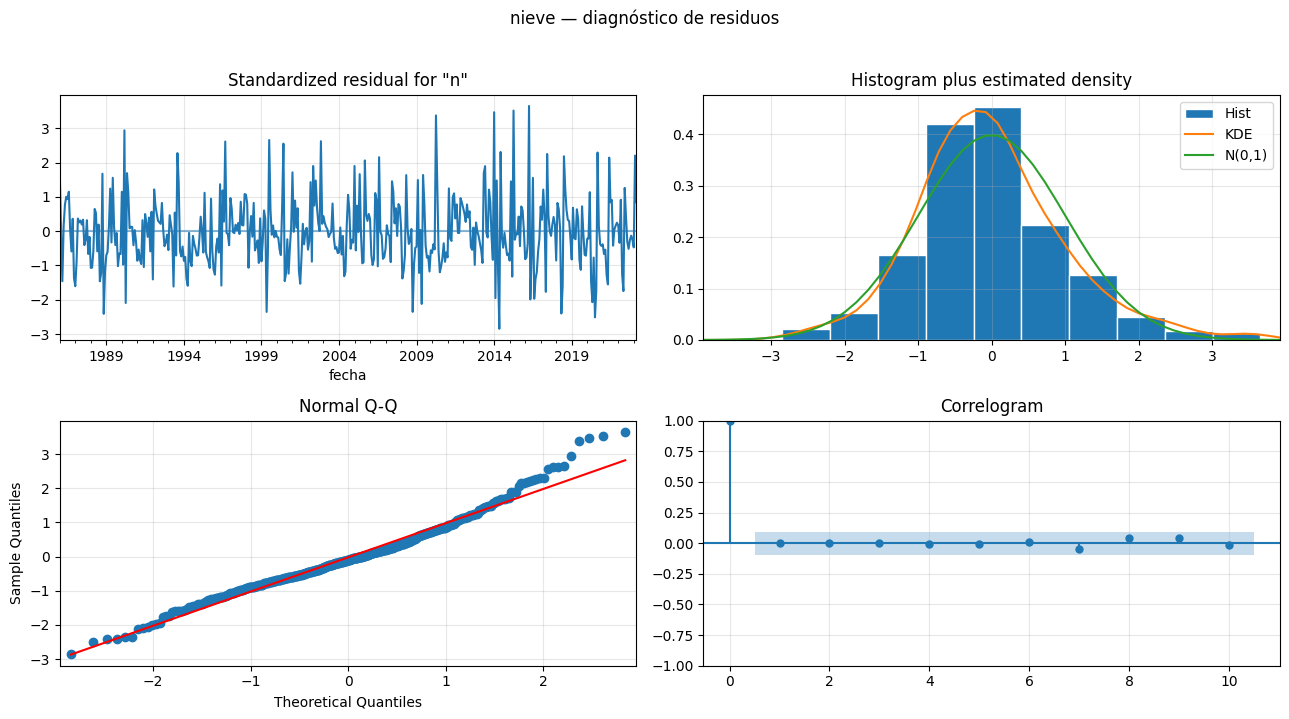

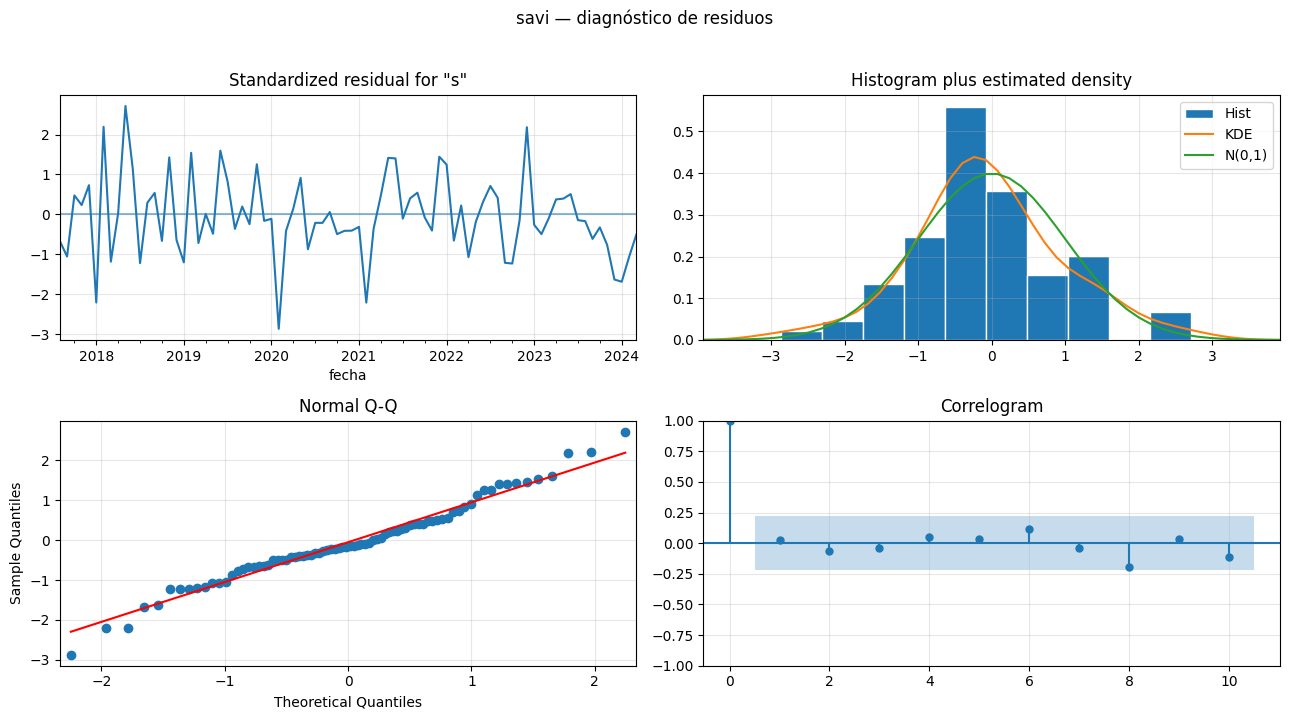

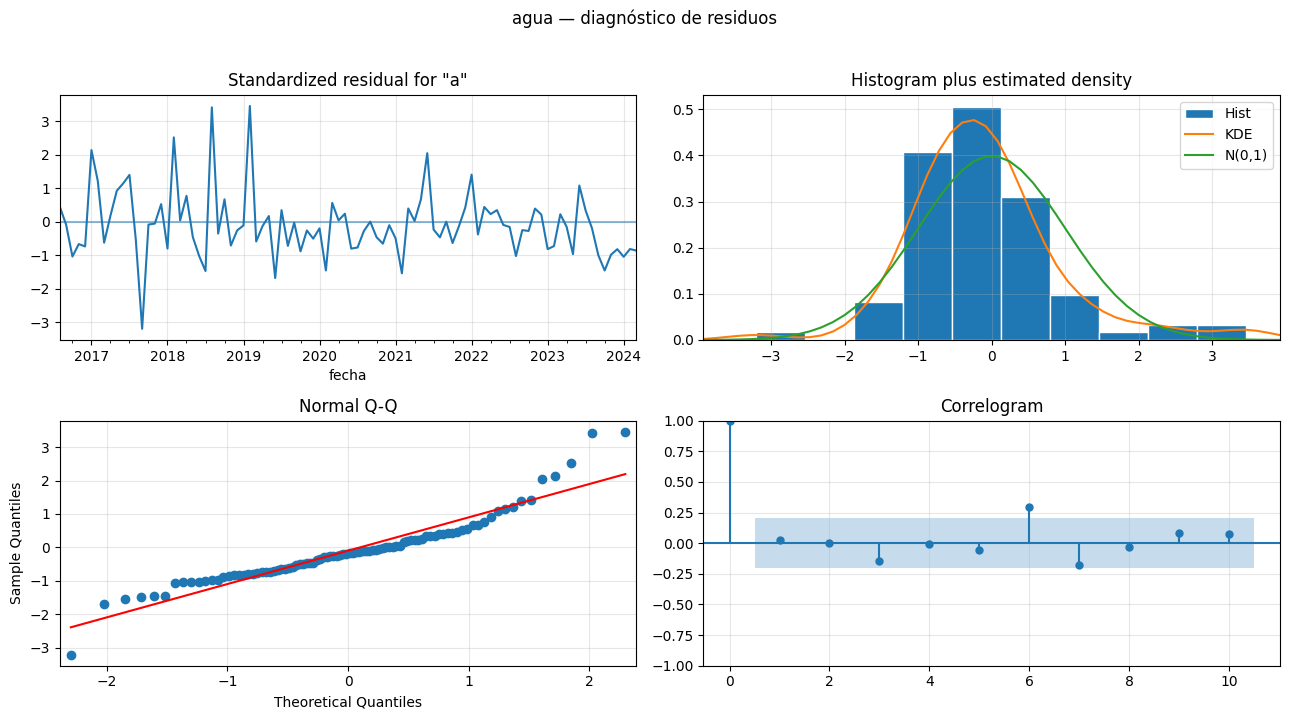

,LB(6) p,LB(12) p,LB(24) p,FAC resid (12),Jarque-Bera p,skew resid,kurtosis resid
serie,,,,,,,
nieve,1.0000,0.9945,0.9873,-0.0222,0.0000,0.5662,4.1267
savi,0.9090,0.7601,0.8722,0.1094,0.4873,0.1341,3.5994
agua,0.0848,0.1694,0.0641,0.0276,0.0000,0.9784,6.0656


Ljung-Box H0: no hay autocorrelación hasta ese rezago (rechazar = queda estructura).
Jarque-Bera H0: los residuos son normales.


In [8]:
for nombre in SERIES_T:
    fig = AJUSTES[nombre].plot_diagnostics(figsize=(13, 7))
    fig.suptitle(f'{nombre} — diagnóstico de residuos', y=1.02)
    plt.tight_layout(); plt.show()

filas = []
for nombre, res in AJUSTES.items():
    lb = res.test_serial_correlation(method='ljungbox', lags=[6, 12, 24])[0]
    jb = res.test_normality('jarquebera')[0]
    fac12 = acf(res.resid.iloc[res.loglikelihood_burn:].values, nlags=24, fft=True)[12]
    filas.append({'serie': nombre, 'LB(6) p': lb[1][0], 'LB(12) p': lb[1][1], 'LB(24) p': lb[1][2],
                  'FAC resid (12)': fac12, 'Jarque-Bera p': jb[1],
                  'skew resid': jb[2], 'kurtosis resid': jb[3]})
display(pd.DataFrame(filas).set_index('serie').round(4))
print('Ljung-Box H0: no hay autocorrelación hasta ese rezago (rechazar = queda estructura).')
print('Jarque-Bera H0: los residuos son normales.')

## 7. SARIMA vs. modelo sin componente estacional *(punto 12)*

Ablación: se reestima cada modelo con los mismos $(p,d,q)$ pero con $P=D=Q=0$. Si empeora el AIC y deja
autocorrelación en el rezago 12, la representación estacional es necesaria.

In [9]:
fac12 = lambda r: acf(r.resid.iloc[r.loglikelihood_burn:].values, nlags=24, fft=True)[12]

filas = []
for nombre, m in MODELOS.items():
    sar = AJUSTES[nombre]
    ari = ajustar(TRAIN[nombre], m['order'], (0, 0, 0, 0))
    filas.append({'serie': nombre, 'modelo': f'SARIMA{m["order"]}x{m["seasonal_order"]}',
                  'AIC SARIMA': sar.aic, 'AIC sin estac.': ari.aic,
                  'LB(12) p SARIMA': sar.test_serial_correlation(method='ljungbox', lags=[12])[0][1][0],
                  'LB(12) p sin estac.': ari.test_serial_correlation(method='ljungbox', lags=[12])[0][1][0],
                  'FAC(12) SARIMA': fac12(sar), 'FAC(12) sin estac.': fac12(ari)})
display(pd.DataFrame(filas).set_index('serie').round(4))
print('AIC más bajo = mejor. LB(12) p alto = residuos limpios en el rezago estacional (deseable).')

,modelo,AIC SARIMA,AIC sin estac.,LB(12) p SARIMA,LB(12) p sin estac.,FAC(12) SARIMA,FAC(12) sin estac.
serie,,,,,,,
nieve,"SARIMA(3, 0, 1)x(1, 0, 1, 12)",1484.0923,1673.4960,0.9945,0.0000,-0.0222,0.2220
savi,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",-372.7660,-356.2378,0.7601,0.0000,0.1094,0.4814
agua,"SARIMA(1, 1, 1)x(1, 0, 1, 12)",938.1338,946.4498,0.1694,0.0072,0.0276,0.2542


AIC más bajo = mejor. LB(12) p alto = residuos limpios en el rezago estacional (deseable).


## 8. Pronóstico *(punto 9)*

Cada modelo se **reestima sobre la serie completa** (training + testing) con los mismos órdenes ya validados.
Horizonte: 24 meses para `nieve`, 12 para `savi` y `agua`.

nieve: reestimado sobre 471 obs (AIC=1561.70) -> 24 meses (2025-04 a 2027-03)
savi: reestimado sobre 105 obs (AIC=-429.46) -> 12 meses (2025-04 a 2026-03)
agua: reestimado sobre 105 obs (AIC=1049.63) -> 12 meses (2025-04 a 2026-03)


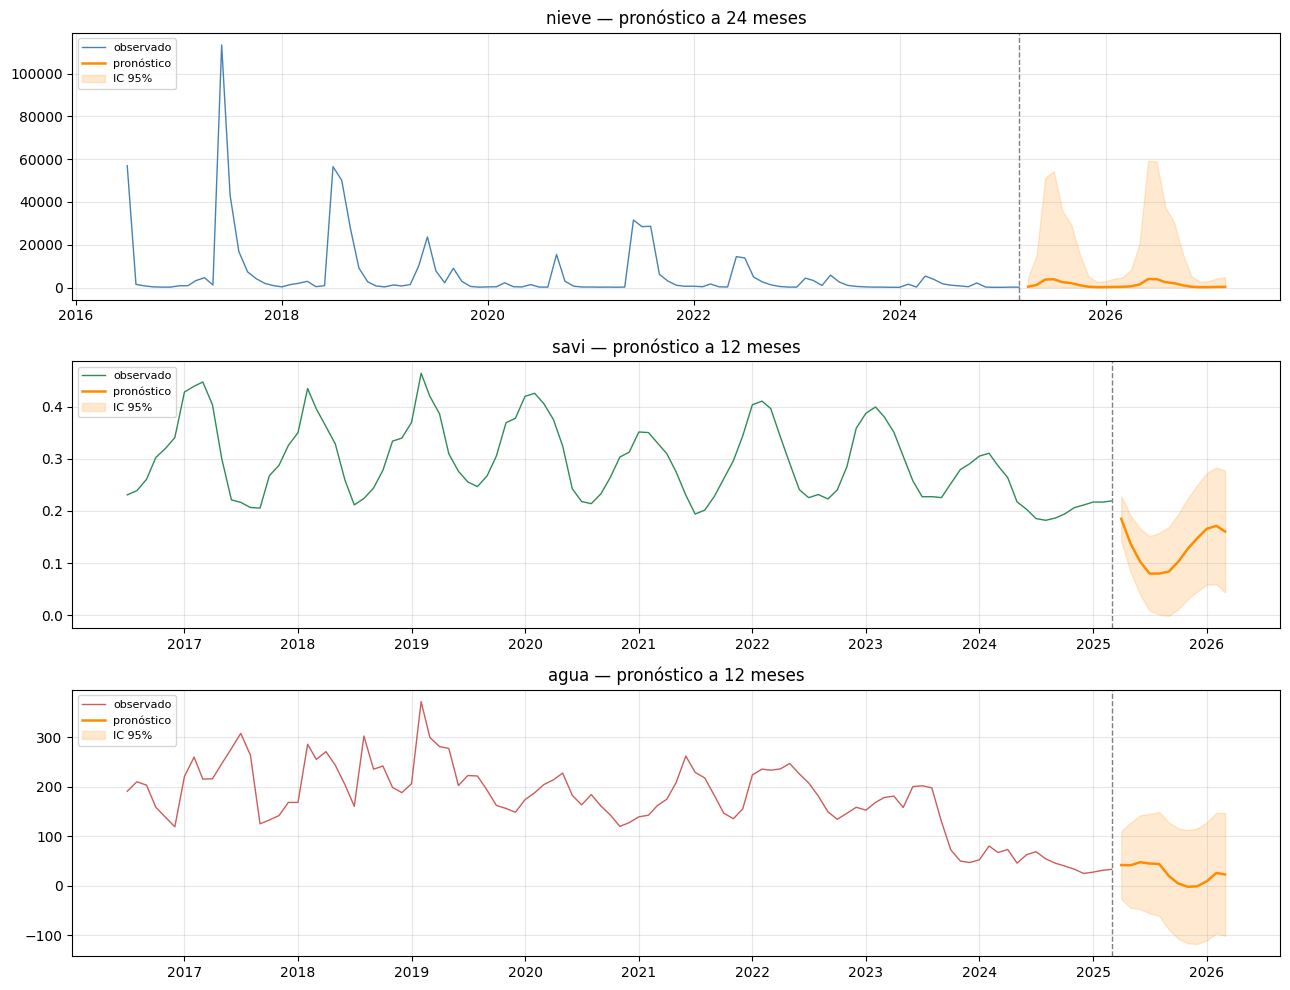

In [10]:
HORIZONTE = {'nieve': 24, 'savi': 12, 'agua': 12}

AJUSTES_FULL, PRONOSTICOS = {}, {}
for nombre, m in MODELOS.items():
    AJUSTES_FULL[nombre] = ajustar(SERIES_T[nombre], m['order'], m['seasonal_order'])
    fc = AJUSTES_FULL[nombre].get_forecast(steps=HORIZONTE[nombre])
    PRONOSTICOS[nombre] = {'pred': fc.predicted_mean, 'ci': fc.conf_int(alpha=0.05)}
    print(f'{nombre}: reestimado sobre {len(SERIES_T[nombre])} obs (AIC={AJUSTES_FULL[nombre].aic:.2f}) '
          f'-> {HORIZONTE[nombre]} meses ({fc.predicted_mean.index[0]:%Y-%m} a '
          f'{fc.predicted_mean.index[-1]:%Y-%m})')

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
for ax, nombre in zip(axes, SERIES_T):
    # a `nieve` se le recorta el historial mostrado para que el pronóstico sea legible
    hist = invertir(nombre, SERIES_T[nombre].loc['2016-07':] if nombre == 'nieve' else SERIES_T[nombre])
    ci = invertir(nombre, PRONOSTICOS[nombre]['ci'])
    ax.plot(hist, color=COLORES[nombre], lw=1, label='observado')
    ax.plot(invertir(nombre, PRONOSTICOS[nombre]['pred']), color='darkorange', lw=1.8, label='pronóstico')
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='darkorange', alpha=0.18, label='IC 95%')
    ax.axvline(SERIES_T[nombre].index[-1], color='grey', ls='--', lw=1)
    ax.set_title(f'{nombre} — pronóstico a {HORIZONTE[nombre]} meses')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

## 9. Resumen y exportación

In [11]:
resumen_final = pd.DataFrame([
    {'serie': nombre,
     'modelo': f'SARIMA{MODELOS[nombre]["order"]}x{MODELOS[nombre]["seasonal_order"]}',
     'AIC (train)': AJUSTES[nombre].aic, 'BIC (train)': AJUSTES[nombre].bic,
     **dict(zip(['MAE test', 'RMSE test', 'sMAPE test %'],
                metricas(invertir(nombre, TEST[nombre]).values,
                         invertir(nombre, PRONOSTICOS_TEST[nombre]['pred']).values))),
     'AIC (serie completa)': AJUSTES_FULL[nombre].aic}
    for nombre in SERIES_T]).set_index('serie').round(3)
display(resumen_final)

ruta = os.path.join(CARPETA_SALIDA, '03_resumen_modelos_sarima.csv')
resumen_final.to_csv(ruta)
print(f'\n03_resumen_modelos_sarima.csv ({os.path.getsize(ruta)/1024:.1f} KB) -> {os.path.abspath(ruta)}')

,modelo,AIC (train),BIC (train),MAE test,RMSE test,sMAPE test %,AIC (serie completa)
serie,,,,,,,
nieve,"SARIMA(3, 0, 1)x(1, 0, 1, 12)",1484.092,1512.810,2887.100,4166.343,119.461,1561.696
savi,"SARIMA(0, 1, 1)x(0, 1, 1, 12)",-372.766,-365.620,0.037,0.042,19.558,-429.462
agua,"SARIMA(1, 1, 1)x(1, 0, 1, 12)",938.134,950.743,64.241,67.463,84.871,1049.634



03_resumen_modelos_sarima.csv (0.3 KB) -> /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/03_resumen_modelos_sarima.csv
